In [2]:
import pandas as pd
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
print(df.shape)
df.info()

(180519, 53)
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname              

In [3]:
df = df.drop(columns=['Product Description'])


In [4]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]


Customer Lname           8
Customer Zipcode         3
Order Zipcode       155679
dtype: int64

In [6]:
df['Order Zipcode'] = df['Order Zipcode'].fillna('UNKNOWN')


In [7]:
df['Customer Lname'] = df['Customer Lname'].fillna('UNKNOWN')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(0)

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
import os

In [13]:
# --- categories ---
categories = df[['Category Id', 'Category Name', 'Department Id', 'Department Name']].drop_duplicates(subset='Category Id').reset_index(drop=True)
categories.columns = ['category_id', 'category_name', 'department_id', 'department_name']

In [14]:
# --- products ---
products = df[['Product Card Id', 'Product Name', 'Product Price', 'Product Status', 'Category Id']].drop_duplicates(subset='Product Card Id').reset_index(drop=True)
products.columns = ['product_card_id', 'product_name', 'product_price', 'product_status', 'category_id']

In [15]:
# --- customers ---
customers = df[['Customer Id', 'Customer Fname', 'Customer Lname', 'Customer Email', 'Customer Segment',
                 'Customer City', 'Customer State', 'Customer Street', 'Customer Country', 'Customer Zipcode']].drop_duplicates(subset='Customer Id').reset_index(drop=True)
customers.columns = ['customer_id', 'first_name', 'last_name', 'email', 'segment', 'city', 'state', 'street', 'country', 'zipcode']

In [16]:
# --- orders ---
orders = df[['Order Id', 'Order Customer Id', 'order date (DateOrders)', 'Order Status', 'Order Region',
              'Order State', 'Order City', 'Order Country', 'Order Zipcode', 'Market', 'Type', 'Latitude', 'Longitude']].drop_duplicates(subset='Order Id').reset_index(drop=True)
orders.columns = ['order_id', 'customer_id', 'order_date', 'order_status', 'order_region', 'order_state',
                    'order_city', 'order_country', 'order_zipcode', 'market', 'payment_type', 'latitude', 'longitude']

In [17]:
# --- order_items ---
order_items = df[['Order Item Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Quantity',
                    'Order Item Product Price', 'Order Item Discount', 'Order Item Discount Rate',
                    'Order Item Profit Ratio', 'Sales', 'Order Item Total', 'Order Profit Per Order',
                    'Benefit per order', 'Sales per customer']].reset_index(drop=True)
order_items.columns = ['order_item_id', 'order_id', 'product_card_id', 'quantity', 'product_price',
                         'discount', 'discount_rate', 'profit_ratio', 'sales', 'order_item_total',
                         'profit_per_order', 'benefit_per_order', 'sales_per_customer']


In [18]:
# --- shipments ---
shipments = df[['Order Item Id', 'shipping date (DateOrders)', 'Shipping Mode', 'Delivery Status',
                  'Days for shipping (real)', 'Days for shipment (scheduled)', 'Late_delivery_risk']].reset_index(drop=True)
shipments.columns = ['order_item_id', 'shipping_date', 'shipping_mode', 'delivery_status',
                       'days_for_shipping_real', 'days_for_shipment_scheduled', 'late_delivery_risk']

In [19]:
# --- export all to data/processed/ ---
os.makedirs('../data/processed', exist_ok=True)
categories.to_csv('../data/processed/categories.csv', index=False)
products.to_csv('../data/processed/products.csv', index=False)
customers.to_csv('../data/processed/customers.csv', index=False)
orders.to_csv('../data/processed/orders.csv', index=False)
order_items.to_csv('../data/processed/order_items.csv', index=False)
shipments.to_csv('../data/processed/shipments.csv', index=False)

for name, t in [('categories',categories), ('products',products), ('customers',customers),
                 ('orders',orders), ('order_items',order_items), ('shipments',shipments)]:
    print(name, t.shape)

categories (51, 4)
products (118, 5)
customers (20652, 10)
orders (65752, 13)
order_items (180519, 13)
shipments (180519, 7)


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

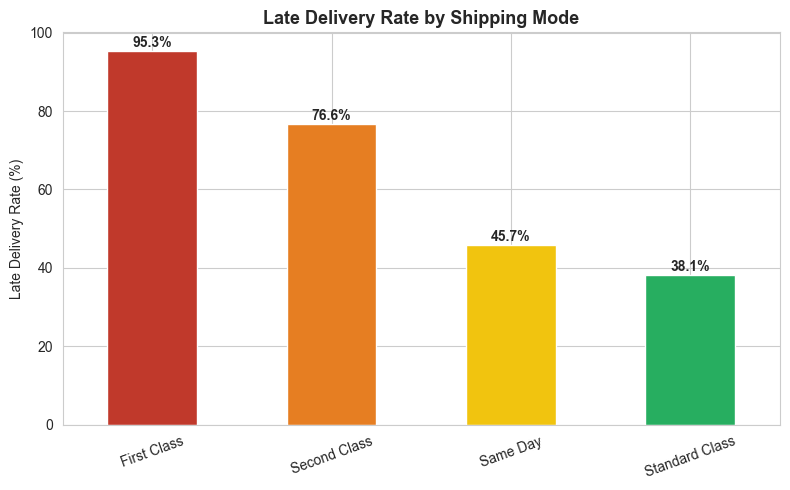

In [21]:
mode_late = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
ax = mode_late.plot(kind='bar', color=['#c0392b','#e67e22','#f1c40f','#27ae60'])
plt.title('Late Delivery Rate by Shipping Mode', fontsize=13, fontweight='bold')
plt.ylabel('Late Delivery Rate (%)')
plt.xlabel('')
plt.xticks(rotation=20)
for i, v in enumerate(mode_late):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/screenshots/late_rate_by_shipping_mode.png')
plt.show()

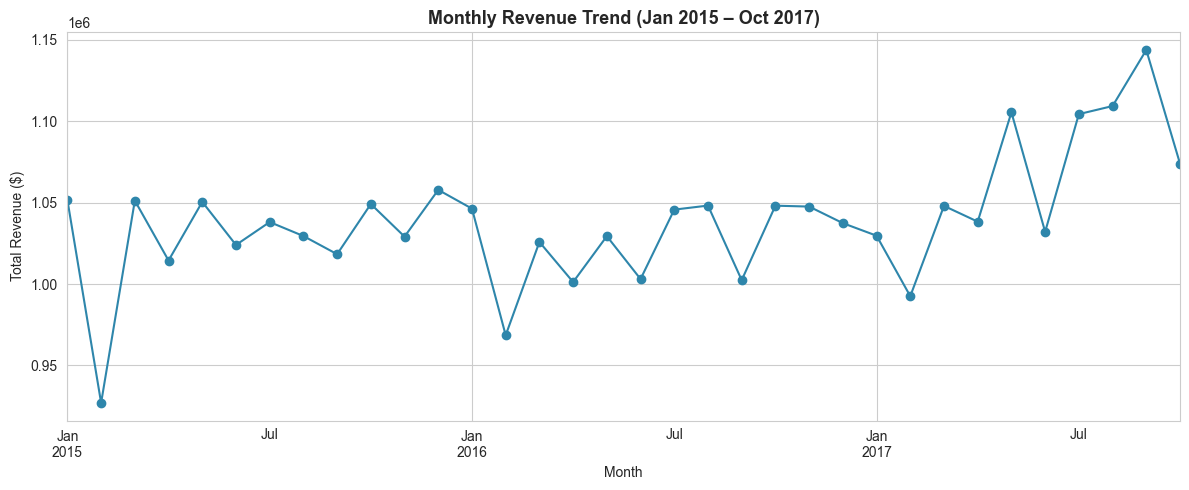

In [22]:
df_trend = df[df['order date (DateOrders)'] < '2017-11-01'].copy()
df_trend['year_month'] = df_trend['order date (DateOrders)'].dt.to_period('M')
monthly_rev = df_trend.groupby('year_month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_rev.plot(kind='line', marker='o', color='#2E86AB')
plt.title('Monthly Revenue Trend (Jan 2015 – Oct 2017)', fontsize=13, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('../docs/screenshots/monthly_revenue_trend.png')
plt.show()

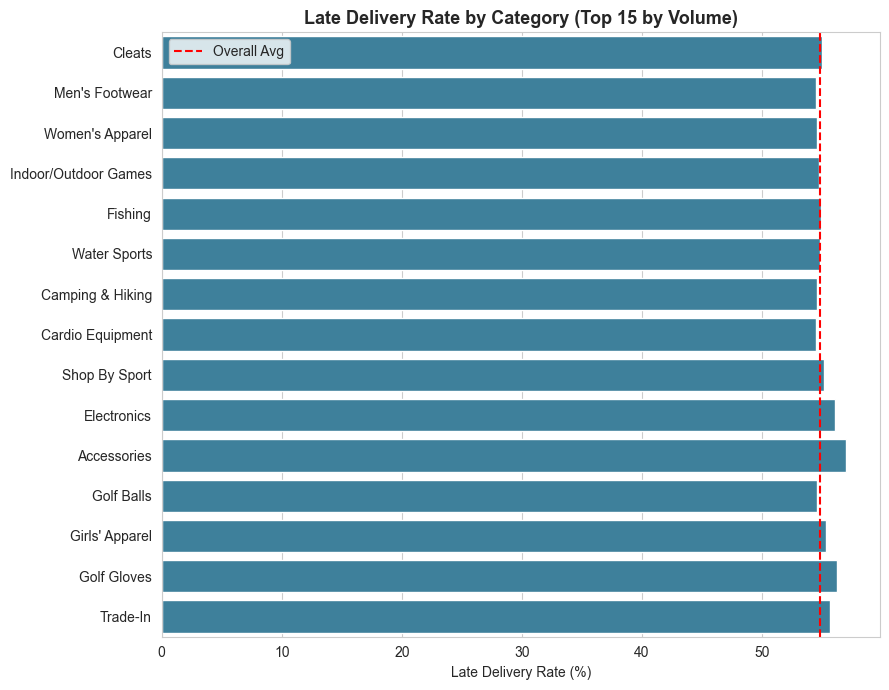

In [23]:
cat_stats = df.groupby('Category Name').agg(
    total=('Late_delivery_risk','count'),
    late_rate=('Late_delivery_risk','mean')
).sort_values('total', ascending=False).head(15)
cat_stats['late_rate'] *= 100

plt.figure(figsize=(9,7))
sns.barplot(x=cat_stats['late_rate'], y=cat_stats.index, color='#2E86AB')
plt.title('Late Delivery Rate by Category (Top 15 by Volume)', fontsize=13, fontweight='bold')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('')
plt.axvline(df['Late_delivery_risk'].mean()*100, color='red', linestyle='--', label='Overall Avg')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/screenshots/late_rate_by_category.png')
plt.show()

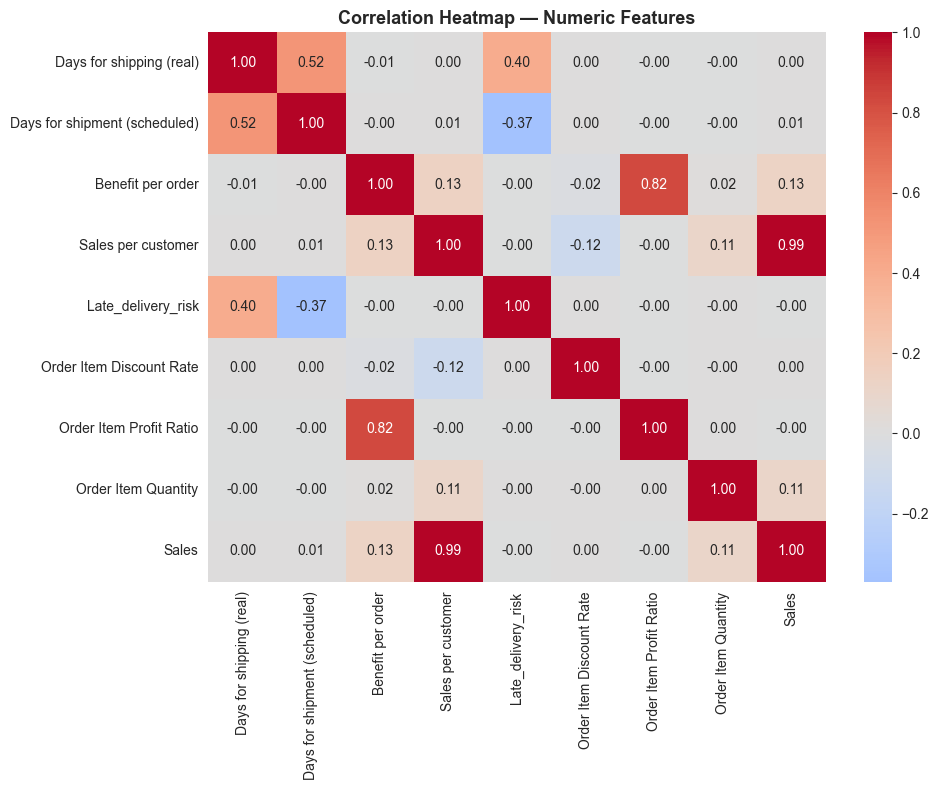

In [24]:
numeric_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order',
                 'Sales per customer', 'Late_delivery_risk', 'Order Item Discount Rate',
                 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/screenshots/correlation_heatmap.png')
plt.show()